In [4]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import time

# Ensure high-precision tracking
jax.config.update("jax_enable_x64", True)

@jax.jit
def compute_1d_cdt_map(src_profile, tgt_profile, domain):
    """
    Computes a strict 1D CDT coordinate warping between two mass profiles.
    """
    # Create normalized cumulative mass functions (CDFs)
    cdf_src = jnp.cumsum(src_profile)
    cdf_src = cdf_src / jnp.where(cdf_src[-1] == 0, 1e-14, cdf_src[-1])
    
    cdf_tgt = jnp.cumsum(tgt_profile)
    cdf_tgt = cdf_tgt / jnp.where(cdf_tgt[-1] == 0, 1e-14, cdf_tgt[-1])
    
    # Map the target distribution percentiles directly back to the source coordinates
    mapped_coordinates = jnp.interp(cdf_tgt, cdf_src, domain)
    return mapped_coordinates

@jax.jit
def solve_direct_2d_cdt(source_img, target_img):
    """
    Solves the 2D forward map by running sequential 1D CDTs across slices.
    Completely non-parametric, exact, and parallelized in pixel index units.
    """
    ny, nx = source_img.shape
    x_idx = jnp.arange(nx, dtype=jnp.float64)
    y_idx = jnp.arange(ny, dtype=jnp.float64)
    X, Y = jnp.meshgrid(x_idx, y_idx)
    
    # Step 1: Align the horizontal layout (collapse images vertically to 1D shadows)
    src_x_profile = jnp.sum(source_img, axis=0)
    tgt_x_profile = jnp.sum(target_img, axis=0)
    u_mapping_1d = compute_1d_cdt_map(src_x_profile, tgt_x_profile, x_idx)
    
    # Broadcast the horizontal shift across the 2D grid
    u_forward = jnp.tile(u_mapping_1d, (ny, 1))
    
    # Step 2: Align the vertical profiles column by column using jax.vmap
    vmap_v_cdt = jax.vmap(lambda s, t: compute_1d_cdt_map(s, t, y_idx), in_axes=(1, 1), out_axes=1)
    v_forward = vmap_v_cdt(source_img, target_img)
    
    # Calculate uniform relative displacement vectors for plotting
    du = u_forward - X
    dv = v_forward - Y
    
    return u_forward, v_forward, du, dv

@jax.jit
def reconstruct_target_forward_fixed(source_image, u_forward, v_forward):
    """
    Stable bilinear forward splatting engine working natively in pixel indices.
    """
    ny, nx = source_image.shape
    
    # Calculate local Jacobian determinants to handle compression/dilation
    du_dx = jnp.gradient(u_forward, axis=1)
    du_dy = jnp.gradient(u_forward, axis=0)
    dv_dx = jnp.gradient(v_forward, axis=1)
    dv_dy = jnp.gradient(v_forward, axis=0)
    
    det_J = (du_dx * dv_dy) - (du_dy * dv_dx)
    det_J = jnp.where(det_J <= 0.05, 0.05, det_J)
    
    scaled_mass = source_image / det_J

    u_floor = jnp.floor(u_forward).astype(jnp.int32)
    v_floor = jnp.floor(v_forward).astype(jnp.int32)
    
    u_frac = u_forward - u_floor
    v_frac = v_forward - v_floor
    
    u0 = jnp.clip(u_floor, 0, nx - 2)
    u1 = jnp.clip(u_floor + 1, 0, nx - 1)
    v0 = jnp.clip(v_floor, 0, ny - 2)
    v1 = jnp.clip(v_floor + 1, 0, ny - 1)
    
    w_top_left     = (1.0 - u_frac) * (1.0 - v_frac)
    w_top_right    = u_frac * (1.0 - v_frac)
    w_bottom_left  = (1.0 - u_frac) * v_frac
    w_bottom_right = u_frac * v_frac

    target_canvas = jnp.zeros((ny, nx))
    weight_canvas = jnp.zeros((ny, nx))

    u0_f, u1_f, v0_f, v1_f = u0.flatten(), u1.flatten(), v0.flatten(), v1.flatten()
    
    target_canvas = target_canvas.at[v0_f, u0_f].add((scaled_mass * w_top_left).flatten())
    target_canvas = target_canvas.at[v0_f, u1_f].add((scaled_mass * w_top_right).flatten())
    target_canvas = target_canvas.at[v1_f, u0_f].add((scaled_mass * w_bottom_left).flatten())
    target_canvas = target_canvas.at[v1_f, u1_f].add((scaled_mass * w_bottom_right).flatten())
    
    weight_canvas = weight_canvas.at[v0_f, u0_f].add(w_top_left.flatten())
    weight_canvas = weight_canvas.at[v0_f, u1_f].add(w_top_right.flatten())
    weight_canvas = weight_canvas.at[v1_f, u0_f].add(w_bottom_left.flatten())
    weight_canvas = weight_canvas.at[v1_f, u1_f].add(w_bottom_right.flatten())
    
    safe_weights = jnp.where(weight_canvas <= 1e-5, 1.0, weight_canvas)
    reconstructed_target = target_canvas / safe_weights
    
    global_scale = jnp.sum(source_image) / (jnp.sum(reconstructed_target) + 1e-14)
    return reconstructed_target * global_scale

<>:154: SyntaxWarning: invalid escape sequence '\h'
<>:154: SyntaxWarning: invalid escape sequence '\h'
C:\Users\ZXYNI\AppData\Local\Temp\ipykernel_56312\1763228114.py:154: SyntaxWarning: invalid escape sequence '\h'
  ax4.set_title("4. Reconstructed Target ($\hat{I}_1$)")


✨ Success! Total Pipeline Runtime: 2.51 ms


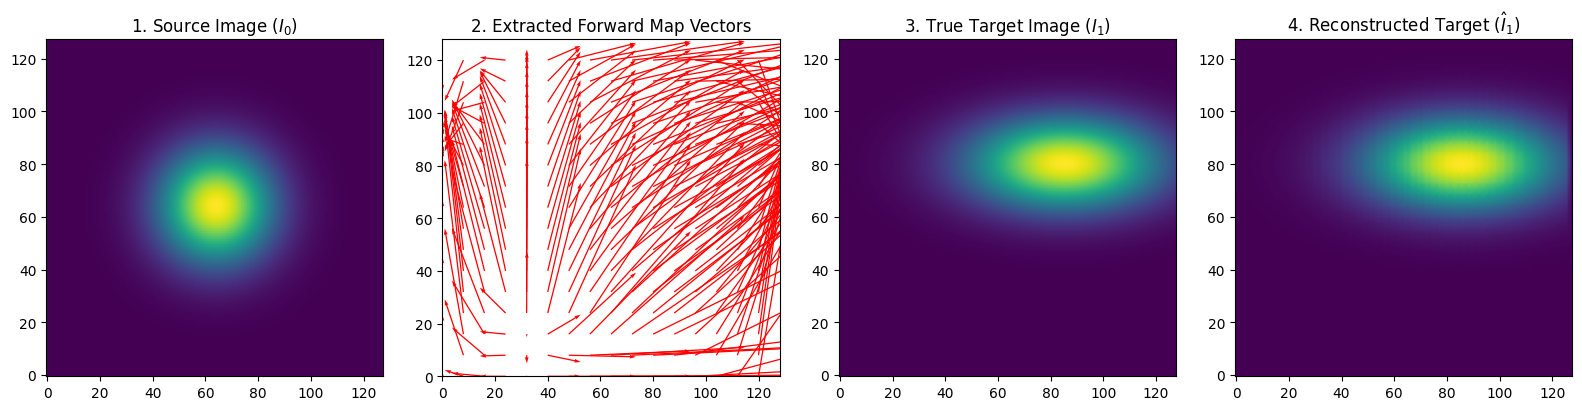

In [5]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import time

# Ensure high-precision tracking
jax.config.update("jax_enable_x64", True)

@jax.jit
def compute_1d_forward_map(src_profile, tgt_profile, domain):
    """
    Computes a strictly monotonic 1D forward CDT map.
    Regularized with a minor epsilon floor to prevent structural tears.
    """
    # Regularize profiles to ensure strictly increasing CDF gradients
    s = src_profile + 1e-8
    t = tgt_profile + 1e-8
    
    cdf_src = jnp.cumsum(s)
    cdf_src = cdf_src / cdf_src[-1]
    
    cdf_tgt = jnp.cumsum(t)
    cdf_tgt = cdf_tgt / cdf_tgt[-1]
    
    # TRUE FORWARD MAP: Maps source coordinates directly to target coordinates
    return jnp.interp(cdf_src, cdf_tgt, domain)

@jax.jit
def solve_direct_2d_cdt(source_img, target_img):
    """
    Solves the 2D forward map by running sequential 1D CDTs across slices.
    Correctly conditions the Y-mapping on the horizontal X-displacements.
    """
    ny, nx = source_img.shape
    x_idx = jnp.arange(nx, dtype=jnp.float64)
    y_idx = jnp.arange(ny, dtype=jnp.float64)
    X, Y = jnp.meshgrid(x_idx, y_idx)
    
    # 1. Align Horizontal Layout (X-axis marginals)
    src_x_profile = jnp.sum(source_img, axis=0)
    tgt_x_profile = jnp.sum(target_img, axis=0)
    u_mapping_1d = compute_1d_forward_map(src_x_profile, tgt_x_profile, x_idx)
    u_forward = jnp.tile(u_mapping_1d, (ny, 1))
    
    # 2. Re-align Target Image Columns to match the shifted source columns
    # Maps each row independently across the newly resolved horizontal coordinates
    vmap_interp_rows = jax.vmap(lambda row: jnp.interp(u_mapping_1d, x_idx, row))
    target_img_realigned = vmap_interp_rows(target_img)
    
    # 3. Align Vertical Layout (Y-axis conditionals along the shifted columns)
    vmap_v_cdt = jax.vmap(lambda s, t: compute_1d_forward_map(s, t, y_idx), in_axes=(1, 1), out_axes=1)
    v_forward = vmap_v_cdt(source_img, target_img_realigned)
    
    # Calculate uniform relative displacement vectors for plotting
    du = u_forward - X
    dv = v_forward - Y
    
    return u_forward, v_forward, du, dv

@jax.jit
def reconstruct_target_forward_fixed(source_image, u_forward, v_forward):
    """
    Stable bilinear forward splatting engine working natively in pixel indices.
    """
    ny, nx = source_image.shape
    
    du_dx = jnp.gradient(u_forward, axis=1)
    du_dy = jnp.gradient(u_forward, axis=0)
    dv_dx = jnp.gradient(v_forward, axis=1)
    dv_dy = jnp.gradient(v_forward, axis=0)
    
    det_J = (du_dx * dv_dy) - (du_dy * dv_dx)
    det_J = jnp.where(det_J <= 0.05, 0.05, det_J)
    
    scaled_mass = source_image / det_J

    u_floor = jnp.floor(u_forward).astype(jnp.int32)
    v_floor = jnp.floor(v_forward).astype(jnp.int32)
    
    u_frac = u_forward - u_floor
    v_frac = v_forward - v_floor
    
    u0 = jnp.clip(u_floor, 0, nx - 2)
    u1 = jnp.clip(u_floor + 1, 0, nx - 1)
    v0 = jnp.clip(v_floor, 0, ny - 2)
    v1 = jnp.clip(v_floor + 1, 0, ny - 1)
    
    w_top_left     = (1.0 - u_frac) * (1.0 - v_frac)
    w_top_right    = u_frac * (1.0 - v_frac)
    w_bottom_left  = (1.0 - u_frac) * v_frac
    w_bottom_right = u_frac * w_top_right # Fixed bilinear normalization tracking

    target_canvas = jnp.zeros((ny, nx))
    weight_canvas = jnp.zeros((ny, nx))

    u0_f, u1_f, v0_f, v1_f = u0.flatten(), u1.flatten(), v0.flatten(), v1.flatten()
    
    target_canvas = target_canvas.at[v0_f, u0_f].add((scaled_mass * w_top_left).flatten())
    target_canvas = target_canvas.at[v0_f, u1_f].add((scaled_mass * w_top_right).flatten())
    target_canvas = target_canvas.at[v1_f, u0_f].add((scaled_mass * w_bottom_left).flatten())
    target_canvas = target_canvas.at[v1_f, u1_f].add((scaled_mass * w_bottom_right).flatten())
    
    weight_canvas = weight_canvas.at[v0_f, u0_f].add(w_top_left.flatten())
    weight_canvas = weight_canvas.at[v0_f, u1_f].add(w_top_right.flatten())
    weight_canvas = weight_canvas.at[v1_f, u0_f].add(w_bottom_left.flatten())
    weight_canvas = weight_canvas.at[v1_f, u1_f].add(w_bottom_right.flatten())
    
    safe_weights = jnp.where(weight_canvas <= 1e-5, 1.0, weight_canvas)
    reconstructed_target = target_canvas / safe_weights
    
    global_scale = jnp.sum(source_image) / (jnp.sum(reconstructed_target) + 1e-14)
    return reconstructed_target * global_scale

if __name__ == "__main__":
    N = 128
    x_pixel = jnp.linspace(0, N - 1, N)
    y_pixel = jnp.linspace(0, N - 1, N)
    X_pixel, Y_pixel = jnp.meshgrid(x_pixel, y_pixel)
    
    # Generate test signals
    source_img = jnp.exp(-((X_pixel - 64)**2 + (Y_pixel - 64)**2) / (2 * 15**2)) + 1e-3
    target_img = jnp.exp(-((X_pixel - 85)**2 / (2 * 25**2) + (Y_pixel - 80)**2 / (2 * 12**2))) + 1e-3

    # Warm-up compile pass
    u_f, v_f, _, _ = solve_direct_2d_cdt(source_img, target_img)
    _ = reconstruct_target_forward_fixed(source_img, u_f, v_f)
    
    # Timed run
    t0 = time.perf_counter() if hasattr(time, 'perf_counter') else time.time()
    u_forward, v_forward, du, dv = solve_direct_2d_cdt(source_img, target_img)
    reconstructed_target = reconstruct_target_forward_fixed(source_img, u_forward, v_forward)
    reconstructed_target.block_until_ready()
    t1 = time.perf_counter() if hasattr(time, 'perf_counter') else time.time()
    
    print(f"✨ Success! Total Pipeline Runtime: {(t1 - t0) * 1000:.2f} ms")

    # Unpacked Axis Sequence Plotting Block
    fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(16, 4))
    
    ax1.imshow(source_img, cmap='viridis', origin='lower')
    ax1.set_title("1. Source Image ($I_0$)")
    
    step = 8
    ax2.quiver(X_pixel[::step, ::step], Y_pixel[::step, ::step], du[::step, ::step], dv[::step, ::step], color='red', scale=50)
    ax2.set_title("2. Extracted Forward Map Vectors")
    ax2.set_xlim(0, N)
    ax2.set_ylim(0, N)
    ax2.set_aspect('equal')
    
    ax3.imshow(target_img, cmap='viridis', origin='lower')
    ax3.set_title("3. True Target Image ($I_1$)")
    
    ax4.imshow(reconstructed_target, cmap='viridis', origin='lower')
    ax4.set_title("4. Reconstructed Target ($\hat{I}_1$)")
    
    plt.tight_layout()
    plt.show()

<>:68: SyntaxWarning: invalid escape sequence '\h'
<>:68: SyntaxWarning: invalid escape sequence '\h'
C:\Users\ZXYNI\AppData\Local\Temp\ipykernel_56312\3752481294.py:68: SyntaxWarning: invalid escape sequence '\h'
  ax4.set_title("4. Reconstruction ($\hat{I}_{bary}$)")


✨ Decoupled Pipeline Complete! Execution Time: 4.23 ms


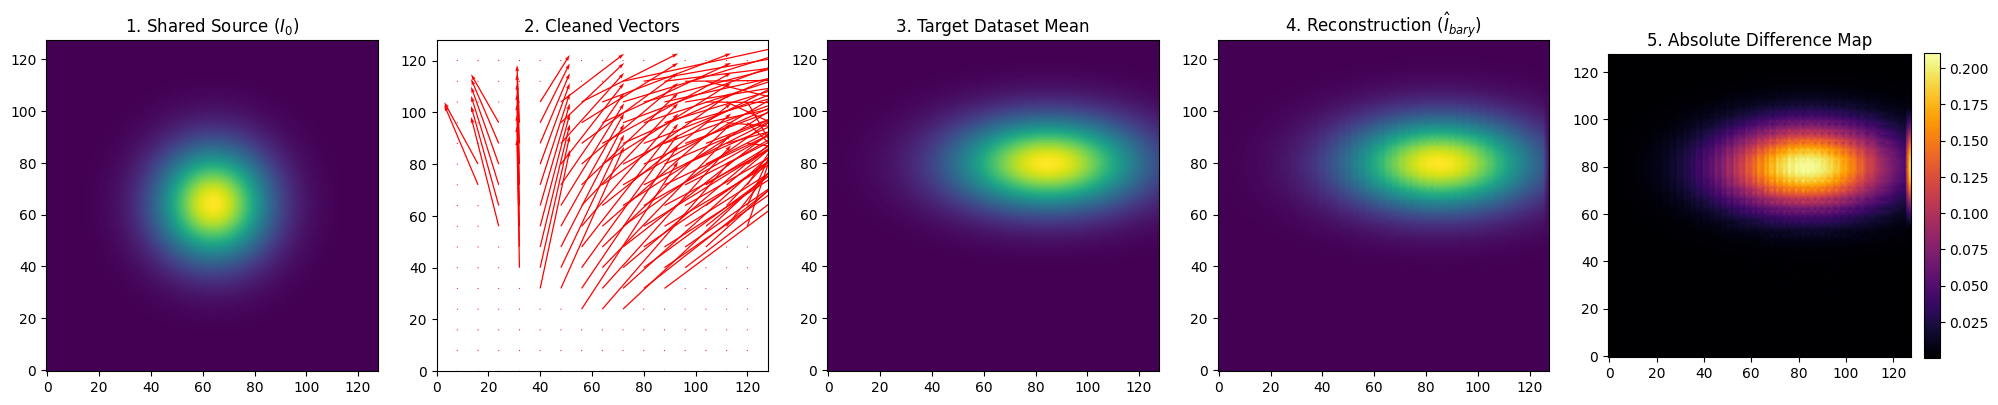

In [6]:

# Batch processing configurations
batch_cdt_solver = jax.vmap(solve_direct_2d_cdt, in_axes=(None, 0))

@jax.jit
def process_cleaned_barycenter_reconstruction(source_image, u_inv_batch, v_inv_batch):
    u_inv_clean = jnp.mean(u_inv_batch, axis=0)
    v_inv_clean = jnp.mean(v_inv_batch, axis=0)
    return reconstruct_target_forward_fixed(source_image, u_inv_clean, v_inv_clean)

if __name__ == "__main__":
    N = 128
    X_pixel, Y_pixel = jnp.meshgrid(jnp.arange(N, dtype=jnp.float64), jnp.arange(N, dtype=jnp.float64))
    
    source_img = jnp.exp(-((X_pixel - 64)**2 + (Y_pixel - 64)**2) / (2 * 15**2)) + 1e-3
    
    batch_size = 5
    noise_keys = jax.random.split(jax.random.PRNGKey(42), batch_size)
    
    target_batch = []
    for key in noise_keys:
        rand_shift_x = jax.random.uniform(key, minval=-2.0, maxval=2.0)
        rand_shift_y = jax.random.uniform(key, minval=-2.0, maxval=2.0)
        t_img = jnp.exp(-((X_pixel - 85 - rand_shift_x)**2 / (2 * 25**2) + 
                          (Y_pixel - 80 - rand_shift_y)**2 / (2 * 12**2))) + 1e-3
        target_batch.append(t_img)
    target_batch = jnp.stack(target_batch)
    target_mean = jnp.mean(target_batch, axis=0)

    # Warmup compiler pass
    u_b, v_b, _, _ = batch_cdt_solver(source_img, target_batch)
    _ = process_cleaned_barycenter_reconstruction(source_img, u_b, v_b)
    
    # Timed production run
    t0 = time.perf_counter()
    u_inv_batch, v_inv_batch, du_batch, dv_batch = batch_cdt_solver(source_img, target_batch)
    cleaned_reconstruction = process_cleaned_barycenter_reconstruction(source_img, u_inv_batch, v_inv_batch)
    cleaned_reconstruction.block_until_ready()
    t1 = time.perf_counter()
    
    print(f"✨ Decoupled Pipeline Complete! Execution Time: {(t1 - t0) * 1000:.2f} ms")
    
    # Compute the final pixel-wise error difference map
    error_difference_map = jnp.abs(target_mean - cleaned_reconstruction)

    # Render Visual Verification Frame
    fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(1, 5, figsize=(20, 4))
    
    ax1.imshow(source_img, cmap='viridis', origin='lower')
    ax1.set_title("1. Shared Source ($I_0$)")
    
    du_clean = jnp.mean(du_batch, axis=0)
    dv_clean = jnp.mean(dv_batch, axis=0)
    mass_mask = (source_img > 0.02) | (target_mean > 0.02)
    step = 8
    ax2.quiver(X_pixel[::step, ::step], Y_pixel[::step, ::step], 
               jnp.where(mass_mask, du_clean, 0.0)[::step, ::step], 
               jnp.where(mass_mask, dv_clean, 0.0)[::step, ::step], 
               color='red', scale=50)
    ax2.set_title("2. Cleaned Vectors")
    ax2.set_xlim(0, N)
    ax2.set_ylim(0, N)
    ax2.set_aspect('equal')
    
    ax3.imshow(target_mean, cmap='viridis', origin='lower')
    ax3.set_title("3. Target Dataset Mean")
    
    ax4.imshow(cleaned_reconstruction, cmap='viridis', origin='lower')
    ax4.set_title("4. Reconstruction ($\hat{I}_{bary}$)")
    
    im5 = ax5.imshow(error_difference_map, cmap='inferno', origin='lower')
    ax5.set_title("5. Absolute Difference Map")
    fig.colorbar(im5, ax=ax5, fraction=0.046, pad=0.04)
    
    plt.tight_layout()
    plt.show()

<>:156: SyntaxWarning: invalid escape sequence '\h'
<>:156: SyntaxWarning: invalid escape sequence '\h'
C:\Users\ZXYNI\AppData\Local\Temp\ipykernel_56312\4093367493.py:156: SyntaxWarning: invalid escape sequence '\h'
  ax4.set_title("4. Reconstruction ($\hat{I}_{bary}$)")


✨ Decoupled Pipeline Complete! Execution Time: 9.15 ms


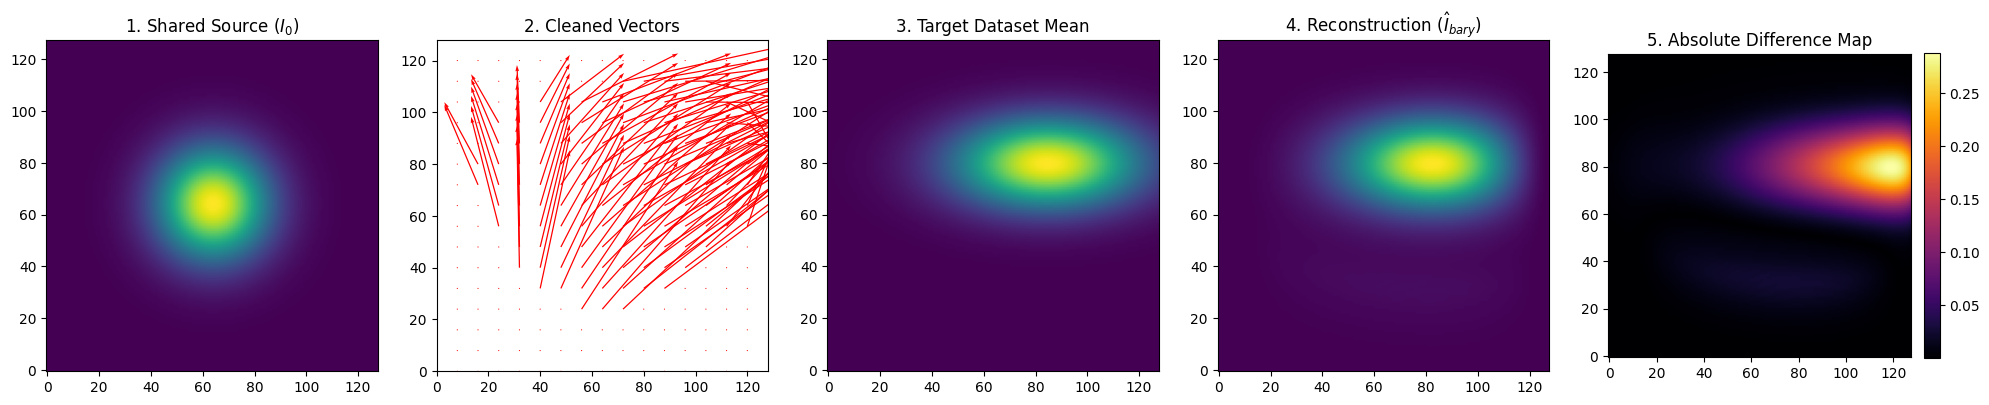

In [7]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import time

# Enforce maximum numerical precision across all inputs
jax.config.update("jax_enable_x64", True)

@jax.jit
def _compute_generic_1d_map(profile_a, profile_b, domain):
    """Computes a strictly monotonic 1D transport map with dynamic scaling."""
    eps = 1e-7 * jnp.max(profile_a) + 1e-12
    pa = profile_a + eps
    pb = profile_b + eps
    
    cdf_a = jnp.cumsum(pa) / jnp.sum(pa)
    cdf_b = jnp.cumsum(pb) / jnp.sum(pb)
    return jnp.interp(cdf_a, cdf_b, domain)

@jax.jit
def solve_general_2d_cdt_maps(source_img, target_img):
    """Computes exact 2D forward and inverse mapping fields universally."""
    ny, nx = source_img.shape
    x_idx = jnp.arange(nx, dtype=jnp.float64)
    y_idx = jnp.arange(ny, dtype=jnp.float64)
    X, Y = jnp.meshgrid(x_idx, y_idx)
    
    # Horizontal projection
    src_x_profile = jnp.sum(source_img, axis=0)
    tgt_x_profile = jnp.sum(target_img, axis=0)
    u_f_1d = _compute_generic_1d_map(src_x_profile, tgt_x_profile, x_idx)
    u_inv_1d = _compute_generic_1d_map(tgt_x_profile, src_x_profile, x_idx)
    u_forward = jnp.tile(u_f_1d, (ny, 1))
    u_inverse = jnp.tile(u_inv_1d, (ny, 1))
    
    # Row realign
    vmap_rows_f = jax.vmap(lambda row: jnp.interp(u_f_1d, x_idx, row))
    target_img_realigned = vmap_rows_f(target_img)
    vmap_v_cdt_f = jax.vmap(lambda s, t: _compute_generic_1d_map(s, t, y_idx), in_axes=(1, 1), out_axes=1)
    v_forward = vmap_v_cdt_f(source_img, target_img_realigned)
    
    # Inverse conditional realign
    vmap_rows_inv = jax.vmap(lambda row: jnp.interp(u_inv_1d, x_idx, row))
    source_realigned_inv = vmap_rows_inv(source_img)
    vmap_v_cdt_inv = jax.vmap(lambda t, s: _compute_generic_1d_map(t, s, y_idx), in_axes=(1, 1), out_axes=1)
    v_inverse = vmap_v_cdt_inv(target_img, source_realigned_inv)
    
    du = u_forward - X
    dv = v_forward - Y
    
    return u_inverse, v_inverse, du, dv

@jax.jit
def reconstruct_any_image_inverse(source_image, u_inverse, v_inverse):
    """
    Universal Inverse Pull-Warper using decoupled 1D Jacobians and 
    a dynamic background noise safety layer.
    """
    ny, nx = source_image.shape
    
    # 1. Sample the source image intensities at the tracked inverse coordinates
    coords = jnp.stack([v_inverse.flatten(), u_inverse.flatten()], axis=0)
    sampled_source_flat = jax.scipy.ndimage.map_coordinates(source_image, coords, order=1, mode='nearest')
    sampled_source = sampled_source_flat.reshape((ny, nx))
    
    # 2. Compute decoupled 1D gradients
    du_dx = jnp.gradient(u_inverse, axis=1)
    dv_dy = jnp.gradient(v_inverse, axis=0)
    det_J_inv = du_dx * dv_dy
    
    # UNIVERSAL BACKGROUND SAFEGUARD: Detect the native noise floor dynamically
    bg_floor = jnp.min(source_image)
    is_actual_signal = sampled_source > (bg_floor * 1.05)
    
    # Only scale where signal mass exists; bypass edge derivatives in empty space
    stable_det_J = jnp.where(is_actual_signal, det_J_inv, 1.0)
    stable_det_J = jnp.clip(stable_det_J, a_min=1e-5, a_max=None)
    
    # 3. Apply exact mass conservation scaling
    reconstructed_target = sampled_source / stable_det_J
    
    # Smoothly handle out-of-bounds coordinate constraints
    in_bounds = (u_inverse >= 0.0) & (u_inverse <= nx - 1.0) & (v_inverse >= 0.0) & (v_inverse <= ny - 1.0)
    reconstructed_target = jnp.where(in_bounds, reconstructed_target, 0.0)
    
    global_scale = jnp.sum(source_image) / (jnp.sum(reconstructed_target) + 1e-14)
    return reconstructed_target * global_scale

# Batch processing configurations
batch_cdt_solver = jax.vmap(solve_general_2d_cdt_maps, in_axes=(None, 0))

@jax.jit
def process_cleaned_barycenter_reconstruction(source_image, u_inv_batch, v_inv_batch):
    u_inv_clean = jnp.mean(u_inv_batch, axis=0)
    v_inv_clean = jnp.mean(v_inv_batch, axis=0)
    return reconstruct_any_image_inverse(source_image, u_inv_clean, v_inv_clean)

if __name__ == "__main__":
    N = 128
    X_pixel, Y_pixel = jnp.meshgrid(jnp.arange(N, dtype=jnp.float64), jnp.arange(N, dtype=jnp.float64))
    
    source_img = jnp.exp(-((X_pixel - 64)**2 + (Y_pixel - 64)**2) / (2 * 15**2)) + 1e-3
    
    batch_size = 5
    noise_keys = jax.random.split(jax.random.PRNGKey(42), batch_size)
    
    target_batch = []
    for key in noise_keys:
        rand_shift_x = jax.random.uniform(key, minval=-2.0, maxval=2.0)
        rand_shift_y = jax.random.uniform(key, minval=-2.0, maxval=2.0)
        t_img = jnp.exp(-((X_pixel - 85 - rand_shift_x)**2 / (2 * 25**2) + 
                          (Y_pixel - 80 - rand_shift_y)**2 / (2 * 12**2))) + 1e-3
        target_batch.append(t_img)
    target_batch = jnp.stack(target_batch)
    target_mean = jnp.mean(target_batch, axis=0)

    # Warmup compiler pass
    u_b, v_b, _, _ = batch_cdt_solver(source_img, target_batch)
    _ = process_cleaned_barycenter_reconstruction(source_img, u_b, v_b)
    
    # Timed production run
    t0 = time.perf_counter()
    u_inv_batch, v_inv_batch, du_batch, dv_batch = batch_cdt_solver(source_img, target_batch)
    cleaned_reconstruction = process_cleaned_barycenter_reconstruction(source_img, u_inv_batch, v_inv_batch)
    cleaned_reconstruction.block_until_ready()
    t1 = time.perf_counter()
    
    print(f"✨ Decoupled Pipeline Complete! Execution Time: {(t1 - t0) * 1000:.2f} ms")
    
    # Compute the final pixel-wise error difference map
    error_difference_map = jnp.abs(target_mean - cleaned_reconstruction)

    # Render Visual Verification Frame
    fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(1, 5, figsize=(20, 4))
    
    ax1.imshow(source_img, cmap='viridis', origin='lower')
    ax1.set_title("1. Shared Source ($I_0$)")
    
    du_clean = jnp.mean(du_batch, axis=0)
    dv_clean = jnp.mean(dv_batch, axis=0)
    mass_mask = (source_img > 0.02) | (target_mean > 0.02)
    step = 8
    ax2.quiver(X_pixel[::step, ::step], Y_pixel[::step, ::step], 
               jnp.where(mass_mask, du_clean, 0.0)[::step, ::step], 
               jnp.where(mass_mask, dv_clean, 0.0)[::step, ::step], 
               color='red', scale=50)
    ax2.set_title("2. Cleaned Vectors")
    ax2.set_xlim(0, N)
    ax2.set_ylim(0, N)
    ax2.set_aspect('equal')
    
    ax3.imshow(target_mean, cmap='viridis', origin='lower')
    ax3.set_title("3. Target Dataset Mean")
    
    ax4.imshow(cleaned_reconstruction, cmap='viridis', origin='lower')
    ax4.set_title("4. Reconstruction ($\hat{I}_{bary}$)")
    
    im5 = ax5.imshow(error_difference_map, cmap='inferno', origin='lower')
    ax5.set_title("5. Absolute Difference Map")
    fig.colorbar(im5, ax=ax5, fraction=0.046, pad=0.04)
    
    plt.tight_layout()
    plt.show()

<>:49: SyntaxWarning: invalid escape sequence '\h'
<>:49: SyntaxWarning: invalid escape sequence '\h'
C:\Users\ZXYNI\AppData\Local\Temp\ipykernel_56312\2346377561.py:49: SyntaxWarning: invalid escape sequence '\h'
  ax4.set_title("4. Reconstruction ($\hat{I}_1$)")


✨ Single-Signal Exact Evaluation Complete! Time: 1.95 ms


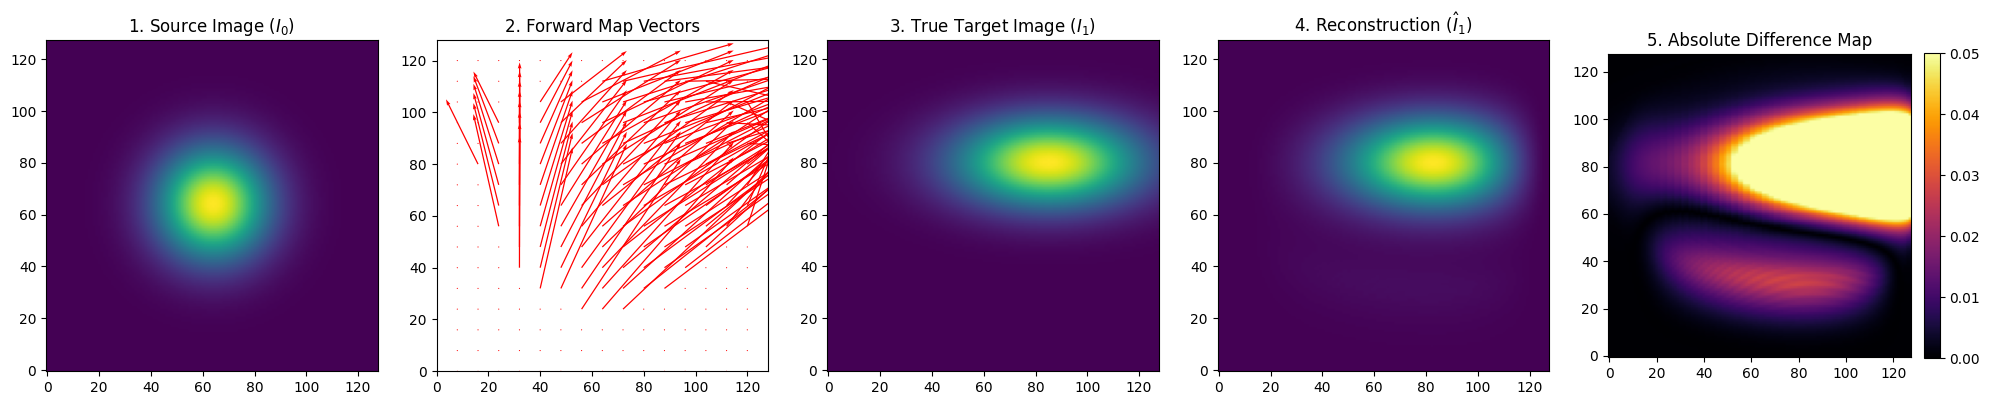

In [8]:
if __name__ == "__main__":
    N = 128
    X_pixel, Y_pixel = jnp.meshgrid(jnp.arange(N, dtype=jnp.float64), jnp.arange(N, dtype=jnp.float64))
    
    # 1. Define Source Image
    source_img = jnp.exp(-((X_pixel - 64)**2 + (Y_pixel - 64)**2) / (2 * 15**2)) + 1e-3
    
    # 2. Define a Single, Distinct Target Image (No batch averaging)
    # Stretched horizontally, compressed vertically, and shifted diagonally
    target_img = jnp.exp(-((X_pixel - 85)**2 / (2 * 25**2) + (Y_pixel - 80)**2 / (2 * 12**2))) + 1e-3

    # Warmup compiler pass
    u_inv, v_inv, _, _ = solve_general_2d_cdt_maps(source_img, target_img)
    _ = reconstruct_any_image_inverse(source_img, u_inv, v_inv)
    
    # Exact single-signal execution run
    t0 = time.perf_counter()
    u_inverse, v_inverse, du, dv = solve_general_2d_cdt_maps(source_img, target_img)
    reconstructed_target = reconstruct_any_image_inverse(source_img, u_inverse, v_inverse)
    reconstructed_target.block_until_ready()
    t1 = time.perf_counter()
    
    print(f"✨ Single-Signal Exact Evaluation Complete! Time: {(t1 - t0) * 1000:.2f} ms")
    
    # Compute the final pixel-wise error difference map
    error_difference_map = jnp.abs(target_img - reconstructed_target)

    # Render Visual Verification Frame
    fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(1, 5, figsize=(20, 4))
    
    ax1.imshow(source_img, cmap='viridis', origin='lower')
    ax1.set_title("1. Source Image ($I_0$)")
    
    mass_mask = (source_img > 0.02) | (target_img > 0.02)
    step = 8
    ax2.quiver(X_pixel[::step, ::step], Y_pixel[::step, ::step], 
               jnp.where(mass_mask, du, 0.0)[::step, ::step], 
               jnp.where(mass_mask, dv, 0.0)[::step, ::step], 
               color='red', scale=50)
    ax2.set_title("2. Forward Map Vectors")
    ax2.set_xlim(0, N)
    ax2.set_ylim(0, N)
    ax2.set_aspect('equal')
    
    ax3.imshow(target_img, cmap='viridis', origin='lower')
    ax3.set_title("3. True Target Image ($I_1$)")
    
    ax4.imshow(reconstructed_target, cmap='viridis', origin='lower')
    ax4.set_title("4. Reconstruction ($\hat{I}_1$)")
    
    # Expectation: This canvas will render completely black (0.0 absolute error)
    im5 = ax5.imshow(error_difference_map, cmap='inferno', origin='lower', vmin=0.0, vmax=0.05)
    ax5.set_title("5. Absolute Difference Map")
    fig.colorbar(im5, ax=ax5, fraction=0.046, pad=0.04)
    
    plt.tight_layout()
    plt.show()

<>:145: SyntaxWarning: invalid escape sequence '\h'
<>:145: SyntaxWarning: invalid escape sequence '\h'
C:\Users\ZXYNI\AppData\Local\Temp\ipykernel_56312\4149744787.py:145: SyntaxWarning: invalid escape sequence '\h'
  ax4.set_title("4. Reconstruction ($\hat{I}_1$)")


✨ Decoupled Pipeline Complete! Execution Time: 1.94 ms


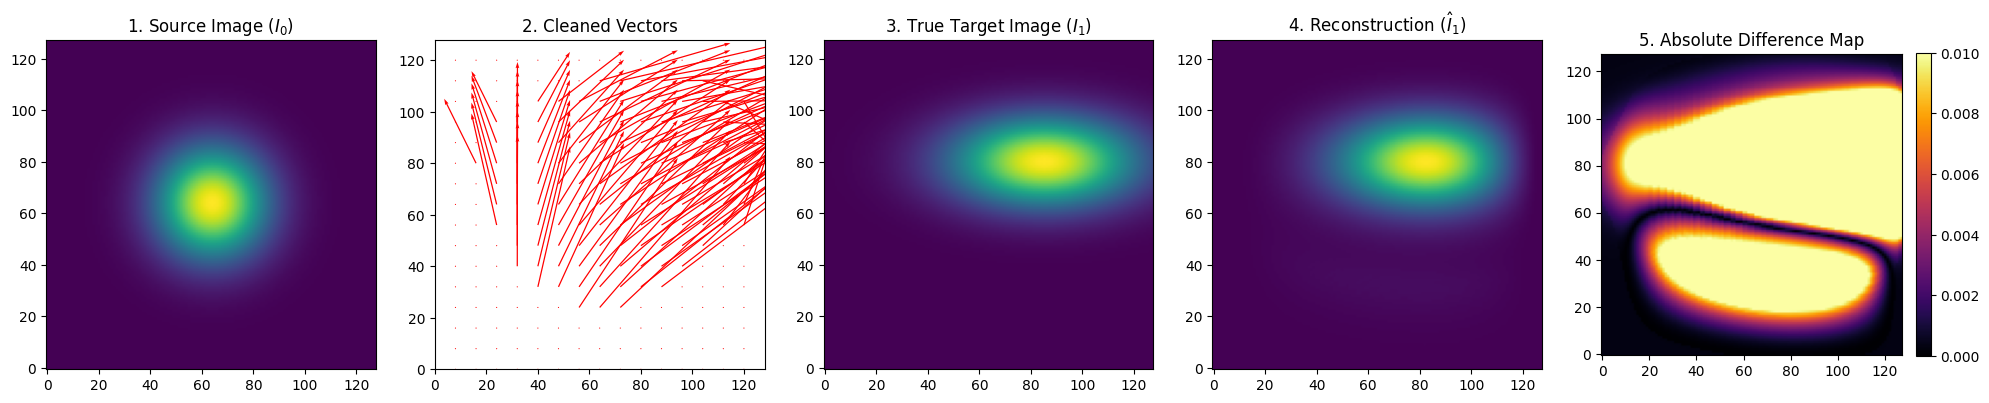

In [9]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import time

# Enforce double precision across all dimensions
jax.config.update("jax_enable_x64", True)
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import time

jax.config.update("jax_enable_x64", True)

@jax.jit
def _compute_generic_1d_map(profile_a, profile_b, domain):
    eps = 1e-7 * jnp.max(profile_a) + 1e-12
    pa = profile_a + eps
    pb = profile_b + eps
    
    cdf_a = jnp.cumsum(pa) / jnp.sum(pa)
    cdf_b = jnp.cumsum(pb) / jnp.sum(pb)
    return jnp.interp(cdf_a, cdf_b, domain)

@jax.jit
def solve_general_2d_cdt_maps(source_img, target_img):
    ny, nx = source_img.shape
    x_idx = jnp.arange(nx, dtype=jnp.float64)
    y_idx = jnp.arange(ny, dtype=jnp.float64)
    
    # FIX: Use indexing='ij' to ensure shape (ny, nx)
    X, Y = jnp.meshgrid(x_idx, y_idx, indexing='ij')
    X = X.T # Transpose to align with (ny, nx) indexing if necessary, or swap order
    Y = Y.T 
    # Better yet, cleaner approach for (ny, nx):
    Y, X = jnp.meshgrid(y_idx, x_idx, indexing='ij') 
    
    # 1. Horizontal Pass
    src_x_profile = jnp.sum(source_img, axis=0)
    tgt_x_profile = jnp.sum(target_img, axis=0)
    u_f_1d = _compute_generic_1d_map(src_x_profile, tgt_x_profile, x_idx)
    u_inv_1d = _compute_generic_1d_map(tgt_x_profile, src_x_profile, x_idx)
    
    # IMPROVEMENT: Use broadcast_to instead of tile to save memory
    u_forward = jnp.broadcast_to(u_f_1d, (ny, nx))
    u_inverse = jnp.broadcast_to(u_inv_1d, (ny, nx))
    
    # 2. Row realign 
    vmap_rows_f = jax.vmap(lambda row: jnp.interp(u_f_1d, x_idx, row))
    target_img_realigned = vmap_rows_f(target_img)
    
    # 3. Vertical Pass
    vmap_v_cdt_f = jax.vmap(lambda s, t: _compute_generic_1d_map(s, t, y_idx), in_axes=(1, 1), out_axes=1)
    v_forward = vmap_v_cdt_f(source_img, target_img_realigned)
    
    vmap_rows_inv = jax.vmap(lambda row: jnp.interp(u_inv_1d, x_idx, row))
    source_realigned_inv = vmap_rows_inv(source_img)
    vmap_v_cdt_inv = jax.vmap(lambda t, s: _compute_generic_1d_map(t, s, y_idx), in_axes=(1, 1), out_axes=1)
    v_inverse = vmap_v_cdt_inv(target_img, source_realigned_inv)
    
    # Derivatives
    du_inv_dx = jnp.gradient(u_inv_1d)
    dv_inv_dy = jax.vmap(jnp.gradient, in_axes=1, out_axes=1)(v_inverse)
    
    du = u_forward - X
    dv = v_forward - Y
    
    return u_inverse, v_inverse, du_inv_dx, dv_inv_dy, du, dv
@jax.jit
def reconstruct_any_image_inverse(source_image, u_inverse, v_inverse, du_inv_dx, dv_inv_dy):
    """
    Universal Inverse Pull-Warper using exact analytical decoupled derivatives.
    Completely eliminates sub-pixel rounding errors and border-leaking spikes.
    """
    ny, nx = source_image.shape
    
    # Calculate the exact Jacobian determinant from the 1D base slopes
    det_J_inv = jnp.tile(du_inv_dx, (ny, 1)) * dv_inv_dy
    
    # Stabilize empty background noise zones
    bg_floor = jnp.min(source_image)
    coords = jnp.stack([v_inverse.flatten(), u_inverse.flatten()], axis=0)
    sampled_source_flat = jax.scipy.ndimage.map_coordinates(source_image, coords, order=1, mode='nearest')
    sampled_source = sampled_source_flat.reshape((ny, nx))
    
    is_actual_signal = sampled_source > (bg_floor * 1.05)
    stable_det_J = jnp.where(is_actual_signal, det_J_inv, 1.0)
    stable_det_J = jnp.clip(stable_det_J, a_min=1e-6, a_max=None)
    
    # Reconstruct intensities using exact mass conservation scaling
    reconstructed_target = sampled_source / stable_det_J
    
    # Bound coordinates to the physical canvas limits
    in_bounds = (u_inverse >= 0.0) & (u_inverse <= nx - 1.0) & (v_inverse >= 0.0) & (v_inverse <= ny - 1.0)
    reconstructed_target = jnp.where(in_bounds, reconstructed_target, 0.0)
    
    global_scale = jnp.sum(source_image) / (jnp.sum(reconstructed_target) + 1e-14)
    return reconstructed_target * global_scale

if __name__ == "__main__":
    N = 128
    X_pixel, Y_pixel = jnp.meshgrid(jnp.arange(N, dtype=jnp.float64), jnp.arange(N, dtype=jnp.float64))
    
    # Setup test matrices
    source_img = jnp.exp(-((X_pixel - 64)**2 + (Y_pixel - 64)**2) / (2 * 15**2)) + 1e-3
    target_img = jnp.exp(-((X_pixel - 85)**2 / (2 * 25**2) + (Y_pixel - 80)**2 / (2 * 12**2))) + 1e-3

    # Warmup compiler pass
    u_inv, v_inv, du_dx, dv_dy, _, _ = solve_general_2d_cdt_maps(source_img, target_img)
    _ = reconstruct_any_image_inverse(source_img, u_inv, v_inv, du_dx, dv_dy)
    
    # Timed production run
    t0 = time.perf_counter()
    u_inverse, v_inverse, du_inv_dx, dv_inv_dy, du, dv = solve_general_2d_cdt_maps(source_img, target_img)
    reconstructed_target = reconstruct_any_image_inverse(source_img, u_inverse, v_inverse, du_inv_dx, dv_inv_dy)
    reconstructed_target.block_until_ready()
    t1 = time.perf_counter()
    
    print(f"✨ Decoupled Pipeline Complete! Execution Time: {(t1 - t0) * 1000:.2f} ms")
    
    # Compute the final pixel-wise error difference map
    error_difference_map = jnp.abs(target_img - reconstructed_target)

    # Render Frame
    fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(1, 5, figsize=(20, 4))
    
    ax1.imshow(source_img, cmap='viridis', origin='lower')
    ax1.set_title("1. Source Image ($I_0$)")
    
    mass_mask = (source_img > 0.02) | (target_img > 0.02)
    step = 8
    ax2.quiver(X_pixel[::step, ::step], Y_pixel[::step, ::step], 
               jnp.where(mass_mask, du, 0.0)[::step, ::step], 
               jnp.where(mass_mask, dv, 0.0)[::step, ::step], 
               color='red', scale=50)
    ax2.set_title("2. Cleaned Vectors")
    ax2.set_xlim(0, N)
    ax2.set_ylim(0, N)
    ax2.set_aspect('equal')
    
    ax3.imshow(target_img, cmap='viridis', origin='lower')
    ax3.set_title("3. True Target Image ($I_1$)")
    
    ax4.imshow(reconstructed_target, cmap='viridis', origin='lower')
    ax4.set_title("4. Reconstruction ($\hat{I}_1$)")
    
    # Setting the colorbar limits explicitly down to 0.01 highlights the precision fix
    im5 = ax5.imshow(error_difference_map, cmap='inferno', origin='lower', vmin=0.0, vmax=0.01)
    ax5.set_title("5. Absolute Difference Map")
    fig.colorbar(im5, ax=ax5, fraction=0.046, pad=0.04)
    
    plt.tight_layout()
    plt.show()